In [34]:
import sys
if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PyMPDATA-examples')

In [35]:
import numpy as np
from matplotlib import pyplot
from open_atmos_jupyter_utils import show_plot, show_anim
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions
from PyMPDATA.boundary_conditions import Extrapolated



In [36]:
from matplotlib.colors import LinearSegmentedColormap

colors = [
    (0.95, 0.85, 0.60),  # beach sand – jasny beż
    (0.70, 0.90, 1.00),  # shallow water – turkus
    (0.00, 0.30, 0.60),  # deep ocean – ciemny niebieski
]

beach_cmap = LinearSegmentedColormap.from_list("beach", colors)

In [37]:
# def plot(frame, *, zlim=None):
#     psi = output['h'][frame]-bathymetry
#     xi, yi = np.indices(psi.shape)
#     fig, ax = pyplot.subplots(subplot_kw={"projection": "3d"}, figsize=(12, 6))
#     ax.plot_wireframe(xi+.5, yi+.5, psi, color='blue', linewidth=.5)
#     if zlim is None:
#         zmin = np.min(psi)
#         zmax = np.max(psi)
#         ax.set_zlim(zmin - 0.02, zmax + 0.02)
#     else:
#         ax.set_zlim(*zlim)

#     ax.set(zlim=zlim, proj_type='ortho', title=f"t / Δt = {frame}", zlabel=r"$\zeta$")
#     for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
#         axis.pane.fill = False
#         axis.pane.set_edgecolor('black')
#         axis.pane.set_alpha(1)
#     for axis in ('x', 'y'):
#         getattr(ax, f'set_{axis}label')(f"{axis} / Δ{axis}")
#     pyplot.colorbar(
#         ax.contourf(xi+.5, yi+.5, bathymetry, zdir='z', offset=zlim[0],cmap=beach_cmap),
#         pad=.1, aspect=10, fraction=.02, label='bathymetry', location='left'
#     ).ax.invert_yaxis()
#     return fig

In [38]:
def plot(frame, *, zlim=None):
    psi = output['h'][frame] - bathymetry
    xi, yi = np.indices(psi.shape)

    fig, ax = pyplot.subplots(subplot_kw={"projection": "3d"}, figsize=(12, 6))
    ax.plot_wireframe(xi+.5, yi+.5, psi, color='blue', linewidth=.5)

    # --- AUTOMATYCZNE SKALOWANIE Z ---
    if zlim is None:
        zmin = np.min(psi)
        zmax = np.max(psi)
        ax.set_zlim(zmin - 0.02, zmax + 0.02)
        offset = zmin - 0.02
    else:
        ax.set_zlim(*zlim)
        offset = zlim[0]

    ax.set(proj_type='ortho', title=f"t / Δt = {frame}", zlabel=r"$\zeta$")
    
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor('black')
        axis.pane.set_alpha(1)
    for axis in ('x', 'y'):
        getattr(ax, f'set_{axis}label')(f"{axis} / Δ{axis}")

    # --- POPRAWIONY CONTOURF ---
    cb = pyplot.colorbar(
        ax.contourf(xi+.5, yi+.5, bathymetry, zdir='z', offset=offset, cmap=beach_cmap),
        pad=.1, aspect=10, fraction=.02, label='bathymetry', location='left'
    )
    cb.ax.invert_yaxis()

    return fig


In [39]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *, h_initial: np.ndarray, options: Options = None):
        """ initializes the solvers for a given initial condition of `h` assuming zero momenta at t=0 """
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        X, Y, grid = 0, 1, h_initial.shape
        stepper = Stepper(options=options, grid=grid,n_threads=1) #klasa która odpowiada za wykonywanie kroków czasowych - kompilowane numbą, numeryczne kroki wykonaywane by uzyskać równanie adwekcji / adekcji - dyfuzji ; ,n_threads=1 - powoduje że wyłaczamy wielowątkowość
        kwargs = {
            'boundary_conditions': [boundary_conditions.Constant(value=0)] * len(grid), #len(grid) - krotka wymiarów - przemnożone to znaczy że skopiowane 
            'halo': options.n_halo,
        } 
        # kwargs = {
        #     'boundary_conditions': [
        #         boundary_conditions.Extrapolated(),
        #         boundary_conditions.Extrapolated()
        #     ],
        #     'halo': options.n_halo,
        # }
        advectees = {
            "h": ScalarField(h_initial, **kwargs), #**kwargs - trzy razy chcemy to samo przekazać więc robimy słownik argumentów funkcji i rozpakujemy go póżniej 
            "uh": ScalarField(np.zeros(grid), **kwargs),
            "vh": ScalarField(np.zeros(grid), **kwargs),
        }
        self.advector = VectorField((  #pole klasy - self.advector
                np.zeros((grid[X] + 1, grid[Y])),
                np.zeros((grid[X], grid[Y] + 1))
            ), **kwargs
        )
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() } #generator - tworzymy nowy słownik - wygenerujemy 

    def __getitem__(self, key): # gdy wywołamy klase np a = A() to element a['coś '] - spowoduje że wywoła się ta funkcja i zwróci coś- ty element słownika   
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()
    
    # def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
    #     """ applies half of the source term in the given direction """
    #     self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h']- bathymetry, axis=axis)
    
    # def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
    #     # g ∂x ζ
    #     grad = np.gradient(self['h'] - bathymetry, axis=axis)
    #     self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * grad
    #     # ======== NOWOŚĆ: DYSSYPACJA W RUN-UP / BREAKING ========
    #     if key in ('uh','vh'):
    #         u = self['uh'] / self['h']
    #         v = self['vh'] / self['h']
    #         speed = np.sqrt(u**2 + v**2)
    #         # kryterium łamania
    #         eta = self['h'] - bathymetry
    #         breaking = (eta / self['h']) > 0.78
    #         # lokalna stała dyssypacji
    #         cd_local = 0.05 * (1 + 20*breaking)
    #         # źródło oporu: - c_d h |u| u
    #         friction = cd_local * self['h'] * speed
    #         if axis == 0:
    #             self[key][:] -= .5 * friction * u
    #         else:
    #             self[key][:] -= .5 * friction * v
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        # --- hydrodynamiczna siła ciśnienia: -gh ∂x ζ ---
        grad = np.gradient(self['h'] - bathymetry, axis=axis)
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * grad
        
        # --- tylko dla równań pędu (uh, vh) ---
        if key in ('uh','vh'):
            h = self['h']
            u = self['uh'] / h
            v = self['vh'] / h
            speed = np.sqrt(u**2 + v**2)

            # wysokość powierzchni
            eta = h - bathymetry

            # kryterium łamania fali Michea
            breaking = eta > 0.78 * h

            # współczynnik tarcia dna (zwiększany tam, gdzie fala łamie się)
            cd = 0.015
            cd_local = cd * (1 + 25 * breaking)
            self[key][:] *= 0.995  # mała dyssypacja

            # tarcie -cd * h * |u| u
            if axis == 0:
                self[key][:] -= .5 * cd_local * h * speed * u
            else:
                self[key][:] -= .5 * cd_local * h * speed * v




    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        # using slices to ensure views (over copies)
        all = slice(None, None) 
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)

        velocity_at_cell_boundaries = velocity[( 
            (all_but_last, all),
            (all, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2 
        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all),
            (all, all_but_first_and_last)
        )[axis]]
        # courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        # assert np.amax(np.abs(courant_number)) <= 1
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        max_c = np.nanmax(np.abs(courant_number))
        if max_c > 1:
            print(f"UWAGA: max Courant = {max_c:.2f}")
            # assert max_c <= 1  # możesz na chwilę zakomentować


    def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):  # definuiuje co się stanie jak wywołamy a() - przykładowo instancję klasy z okrągłym nawiasem 
        """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
        output = {k: [] for k in self.solvers.keys()}
        for it in range(nt + 1): 
            if it != 0:
                mask = self['h'] > eps
                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(n_steps=1)
                for axis, key in enumerate(("uh", "vh")):
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                    self.solvers[key].advance(n_steps=1)
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                # tłumienie przy brzegu
                # beach_zone = 8
                # damping = np.linspace(0, 1, beach_zone)**2  # rośnie ku brzegowi
                # self['uh'][:, -beach_zone:] *= (1 - damping)
                # self['vh'][:, -beach_zone:] *= (1 - damping)
                # tłumienie przy brzegu – ŁAGODNIEJSZE
                beach_zone = 6
                strength = 0.4  # jak bardzo tłumić (0–1)
                damping = strength * (np.linspace(0, 1, beach_zone)**2)
                # factor = (1 - damping)  # od 1 do 1-strength
                # self['uh'][:, -beach_zone:] *= factor
                # self['vh'][:, -beach_zone:] *= factor
                depth = bathymetry[:, -beach_zone:]
                # większa wartość scale tam, gdzie PŁYTKO (łachy), mniejsza tam, gdzie GŁĘBOKO (kanał)
                inv = depth.max() - depth
                scale = inv / (inv.max() + 1e-6)

                self['uh'][:, -beach_zone:] *= (1 - damping * scale)
                self['vh'][:, -beach_zone:] *= (1 - damping * scale)


            if it % outfreq == 0:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())
        return output
   

In [53]:
# grid = (50, 40)
grid = (120, 120)

nx, ny = grid
# x – od oceanu (0) do brzegu (1)
x = np.linspace(0, 1, ny)
y = np.linspace(-1, 1, nx)

X, Y = np.meshgrid(x, y)

# poprawny stok plaży – głęboko na oceanie, płytko przy brzegu
slope = 0.03
base = 0.5 - slope * (x * ny)
base = np.tile(base, (nx, 1))
base = np.maximum(base, 0.05)

# # rip channel – głęboko na środku, ale maleje ku brzegowi
# channel = -0.25 * np.exp(-(Y**2) / 0.15) * (1 - x)
# kanał ripowy — NAJGŁĘBSZY przy brzegu, płytszy w oceanie
# channel = -0.35 * np.exp(-(Y**2) / 0.1) * (x**1.5)
channel = -0.50 * np.exp(-(Y**2) / 0.04) * (x**2.2)

# # łachy piasku (sandbars) – wyniesione po bokach
# bars = (
#     0.12 * np.exp(-((Y - 0.7)**2)/0.06) +
#     0.12 * np.exp(-((Y + 0.7)**2)/0.06)
# ) * (1 - 0.7*x)  # łachy też maleją przy brzegu
# bars = (
#    0.20 * np.exp(-((Y - 0.7)**2)/0.05) +
#    0.20 * np.exp(-((Y + 0.7)**2)/0.05)
# ) * (x**1.2)
bars = (
   0.45 * np.exp(-((Y - 0.8)**2)/0.03) +
   0.45 * np.exp(-((Y + 0.8)**2)/0.03)
) * (x**1.6)

# finalna batymetria
bathymetry = base + channel + bars
bathymetry = np.maximum(bathymetry, 0.05)
x0 = 0.15   # ocean
amplitude = 0.10
width = 0.20   # trochę dłuższa, mniej stroma


wave = amplitude * np.exp(-((x - x0)**2) / width**2)
wave2d = wave[None, :] #* (1 + 0.1*np.cos(2*np.pi*(y[:,None] + np.random.rand())))

h_initial = bathymetry + wave2d
output = ShallowWaterEquationsIntegrator(h_initial=h_initial)(
    nt=1400,
    g=10,
    dt_over_dxy=(0.15, 0.15),
    outfreq=6
)



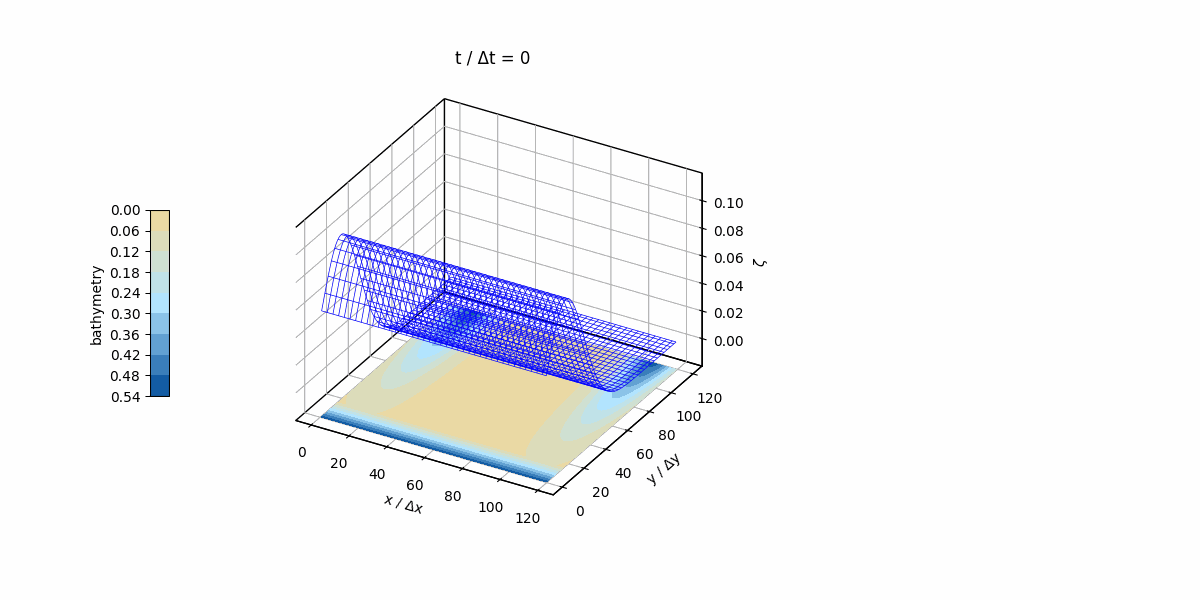

HTML(value="<a href='.\\tmp454z1owh.gif' target='_blank'>.\\tmp454z1owh.gif</a><br>")

In [54]:
show_anim(plot, range(len(output['h'])))


In [42]:
def plot_velocity(frame, skip=3):
    h = output['h'][frame]
    u = output['uh'][frame] / h
    v = output['vh'][frame] / h

    speed = np.sqrt(u**2 + v**2)

    fig, ax = pyplot.subplots(figsize=(6, 4))
    im = ax.pcolormesh(speed.T, shading='auto', cmap='Blues')
    ax.quiver(
        np.arange(0, u.shape[0], skip),
        np.arange(0, u.shape[1], skip),
        u[::skip, ::skip].T,
        v[::skip, ::skip].T,
        scale=5
    )
    pyplot.colorbar(im, label='|u|')
    ax.set_title(f'Pole prędkości, frame={frame}')
    ax.set_xlabel('x / Δx')
    ax.set_ylabel('y / Δy')
    return fig


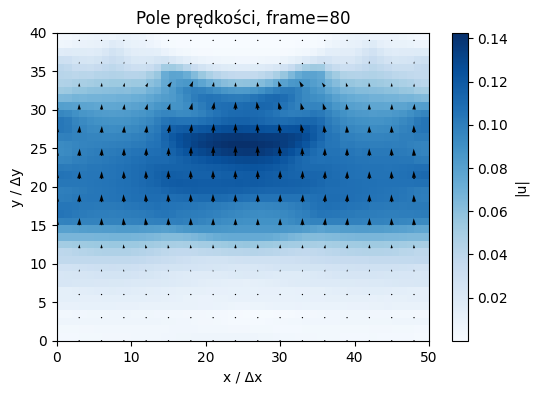

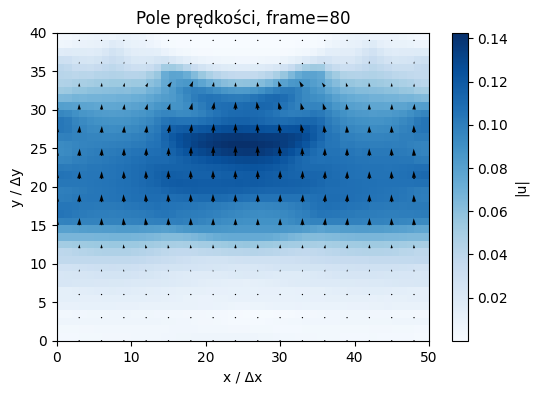

In [43]:
plot_velocity(80)   # np. po przejściu fali na brzeg


In [44]:
# # --- SIATKA ---
# grid = (50, 40)
# nx, ny = grid

# # --- BATYMETRIA Z RIP CURRENT ---
# x = np.linspace(0, 1, ny)      # ocean -> brzeg
# y = np.linspace(-1, 1, nx)     # wzdłuż brzegu
# X, Y = np.meshgrid(x, y)

# slope = 0.03
# base = 0.1 + slope * (x * ny)
# base = np.tile(base, (nx, 1))

# channel = -0.15 * np.exp(-(Y**2) / 0.15)   # trochę płytszy kanał
# bars = (
#     0.12 * np.exp(-((Y - 0.7)**2) / 0.06) +
#     0.12 * np.exp(-((Y + 0.7)**2) / 0.06)
# )

# bathymetry = base + channel + bars
# bathymetry = np.maximum(bathymetry, 0.05)

# # --- FALA NA CAŁEJ SZEROKOŚCI ---
# amplitude = 0.03
# x0 = 0.7
# width = 0.22

# wave = amplitude * np.exp(-((x - x0)**2) / width**2)
# modulation = 1 + 0.1 * np.cos(2*np.pi * (y[:, None] + np.random.rand()))

# wave2d = wave[None, :] * modulation
# h_initial = bathymetry + wave2d
# output = ShallowWaterEquationsIntegrator(h_initial=h_initial)(
#     nt=1200,
#     g=10,
#     dt_over_dxy=(0.05, 0.05),
#     outfreq=6
# )



In [ ]:
import sys
if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PyMPDATA-examples')

import numpy as np
from matplotlib import pyplot
from matplotlib.colors import LinearSegmentedColormap

from open_atmos_jupyter_utils import show_anim
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions

# =============================================================================
# 0. KOLORY DLA PLAŻY
# =============================================================================
colors = [
    (0.95, 0.85, 0.60),  # beach sand – jasny beż
    (0.70, 0.90, 1.00),  # shallow water – turkus
    (0.00, 0.30, 0.60),  # deep ocean – ciemny niebieski
]
beach_cmap = LinearSegmentedColormap.from_list("beach", colors)

# =============================================================================
# 1. FUNKCJA RYSUJĄCA 3D
# =============================================================================
def plot(frame, *, zlim=None):
    psi = output['h'][frame] - bathymetry   # ζ = h - b
    xi, yi = np.indices(psi.shape)

    fig, ax = pyplot.subplots(subplot_kw={"projection": "3d"}, figsize=(12, 6))
    ax.plot_wireframe(xi + .5, yi + .5, psi, color='blue', linewidth=.5)

    # automatyczne skalowanie osi z, żeby fala była zawsze czytelna
    zmin = np.min(psi) if zlim is None else zlim[0]
    zmax = np.max(psi) if zlim is None else zlim[1]
    ax.set_zlim(zmin - 0.02, zmax + 0.02)
    offset = zmin - 0.02

    ax.set(proj_type='ortho', title=f"t / Δt = {frame}", zlabel=r"$\zeta$")

    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor('black')
        axis.pane.set_alpha(1)
    for axis in ('x', 'y'):
        getattr(ax, f'set_{axis}label')(f"{axis} / Δ{axis}")

    cb = pyplot.colorbar(
        ax.contourf(xi + .5, yi + .5, bathymetry, zdir='z',
                    offset=offset, cmap=beach_cmap),
        pad=.1, aspect=10, fraction=.02, label='bathymetry', location='left'
    )
    cb.ax.invert_yaxis()
    return fig

# =============================================================================
# 2. SOLVER RÓWNAŃ PŁYTKIEJ WODY Z GOTOWYM RIP CURRENT
# =============================================================================
class ShallowWaterEquationsIntegrator:
    def __init__(self, *, h_initial: np.ndarray,
                 uh_initial: np.ndarray = None,
                 vh_initial: np.ndarray = None,
                 options: Options = None):
        """
        Inicjalizuje solwer dla zadanych pól h, uh, vh.
        Możemy więc ustawić gotowy prąd wsteczny w uh_initial.
        """
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        X, Y, grid = 0, 1, h_initial.shape

        stepper = Stepper(options=options, grid=grid, n_threads=1)

        kwargs = {
            'boundary_conditions': [boundary_conditions.Constant(value=0)] * len(grid),
            'halo': options.n_halo,
        }

        if uh_initial is None:
            uh_initial = np.zeros(grid)
        if vh_initial is None:
            vh_initial = np.zeros(grid)

        advectees = {
            "h":  ScalarField(h_initial,  **kwargs),
            "uh": ScalarField(uh_initial, **kwargs),
            "vh": ScalarField(vh_initial, **kwargs),
        }

        self.advector = VectorField((
                np.zeros((grid[X] + 1, grid[Y])),
                np.zeros((grid[X],     grid[Y] + 1))
            ), **kwargs
        )
        self.solvers = {k: Solver(stepper, v, self.advector)
                        for k, v in advectees.items()}

    def __getitem__(self, key):
        """Zwraca aktualne pole advectee (h, uh lub vh)."""
        return self.solvers[key].advectee.get()

    # --- prawa strona równań pędu (ciśnienie + tarcie) ---
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        # - g h ∂x ζ   (ζ = h - b)
        grad = np.gradient(self['h'] - bathymetry, axis=axis)
        self[key][:] -= 0.5 * g_times_dt_over_dxy * self['h'] * grad

        # tylko dla uh, vh: tarcie i lekkie tłumienie numeryczne
        if key in ('uh', 'vh'):
            h = self['h']
            u = self['uh'] / h
            v = self['vh'] / h
            speed = np.sqrt(u**2 + v**2)

            # kryterium "łamania" – tu tylko jako wskaźnik silnych ruchów
            eta = h - bathymetry
            breaking = eta > 0.78 * h

            cd = 0.015
            cd_local = cd * (1 + 25 * breaking)

            # lekkie globalne tłumienie
            self[key][:] *= 0.995

            if axis == 0:
                self[key][:] -= 0.5 * cd_local * h * speed * u
            else:
                self[key][:] -= 0.5 * cd_local * h * speed * v

    # --- Courant number (CFL) ---
    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        all_ = slice(None, None)
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)

        velocity_at_cell_boundaries = velocity[(
            (all_but_last, all_),
            (all_, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2

        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all_),
            (all_, all_but_first_and_last)
        )[axis]]
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]

        max_c = np.nanmax(np.abs(courant_number))
        if max_c > 1:
            print(f"UWAGA: max Courant = {max_c:.2f} > 1")

    def __call__(self, *, nt: int, g: float,
                 dt_over_dxy: tuple, outfreq: int,
                 forcing_amplitude: float = 0.12,
                 forcing_period: float = 120.0,
                 eps: float = 1e-7):
        """
        Integruje nt kroków czasowych.
        Dodatkowo wymusza nadchodzącą falę z lewej strony (oceanu),
        ALE rip current jest już wstępnie zadany w uh_initial.
        """
        output = {k: [] for k in self.solvers.keys()}

        for it in range(nt + 1):
            # --- wymuszenie falowe na oceanie (lewa krawędź) ---
            # sinus w czasie, identyczny wzdłuż brzegu
            phase = 2 * np.pi * (it / forcing_period)
            eta_in = forcing_amplitude * np.sin(phase)
            # stan spokojny był: h = bathymetry
            self['h'][:, 0] = bathymetry[:, 0] + eta_in

            if it != 0:
                mask = self['h'] > eps

                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key,
                                                 mask=mask, dt_over_dxy=dt_over_dxy)

                # ciągłość masy
                self.solvers["h"].advance(n_steps=1)

                # równania pędu w dwóch krokach (Strang splitting)
                for axis, key in enumerate(("uh", "vh")):
                    self._apply_half_rhs(key=key, axis=axis,
                                         g_times_dt_over_dxy=g * dt_over_dxy[axis])
                    self.solvers[key].advance(n_steps=1)
                    self._apply_half_rhs(key=key, axis=axis,
                                         g_times_dt_over_dxy=g * dt_over_dxy[axis])

            # zapisywanie co outfreq kroków
            if it % outfreq == 0:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())

        return output

# =============================================================================
# 3. BATYMETRIA: PLAŻA + ŁACHY + GOTOWY KANAŁ RIPOWY
# =============================================================================
grid = (120, 120)      # większa siatka, żeby rip był wyraźniejszy
nx, ny = grid

# x – od oceanu (0) do brzegu (1)
x = np.linspace(0, 1, ny)
# y – wzdłuż brzegu
y = np.linspace(-1, 1, nx)
X, Y = np.meshgrid(x, y)

# stok plaży: głęboko na oceanie, płytko przy brzegu
slope = 0.03
base = 0.5 - slope * (x * ny)
base = np.tile(base, (nx, 1))
base = np.maximum(base, 0.05)

# kanał ripowy — najgłębszy przy brzegu, w osi Y=0
channel = -0.50 * np.exp(-(Y**2) / 0.04) * (x**2.2)

# łachy piaskowe po bokach – wysokie, bardziej przy brzegu
bars = (
   0.45 * np.exp(-((Y - 0.8)**2)/0.03) +
   0.45 * np.exp(-((Y + 0.8)**2)/0.03)
) * (x**1.6)

bathymetry = base + channel + bars
bathymetry = np.maximum(bathymetry, 0.05)

# =============================================================================
# 4. STAN POCZĄTKOWY: GOTOWY RIP CURRENT + JEDNA FALA NADCHODZĄCA
# =============================================================================
# fala początkowa (na oceanie), ale rip current JUŻ ISTNIEJE
x0 = 0.15    # pozycja środka fali (na oceanie)
amplitude_ic = 0.10
width_ic = 0.20

wave = amplitude_ic * np.exp(-((x - x0)**2) / width_ic**2)
wave2d = wave[None, :]  # fala jednorodna wzdłuż brzegu

h_initial = bathymetry + wave2d

# --- wstępny prąd wsteczny ---
uh0 = np.zeros_like(bathymetry)
vh0 = np.zeros_like(bathymetry)

# najgłębsza część kanału – tam zadamy prąd od brzegu do oceanu
rip_mask = (channel < 0.7 * channel.min())   # mocno negatywna część kanału

# prędkość bardziej ujemna w najgłębszym miejscu
rel_depth = np.abs(channel[rip_mask]) / np.abs(channel).max()
uh0[rip_mask] = -0.25 * (rel_depth**1.5)   # strumień od brzegu do oceanu

# =============================================================================
# 5. SYMULACJA: KOLEJNE FALE NA JUŻ ISTNIEJĄCYM RIP CURRENT
# =============================================================================
g = 12.0                 # trochę większa "grawitacja" = silniejsze setupy
dt_over_dxy = (0.05, 0.05)
nt = 1400
outfreq = 6

integrator = ShallowWaterEquationsIntegrator(
    h_initial=h_initial,
    uh_initial=uh0,
    vh_initial=vh0
)

output = integrator(
    nt=nt,
    g=g,
    dt_over_dxy=dt_over_dxy,
    outfreq=outfreq,
    forcing_amplitude=0.08,   # amplituda fal dochodzących z oceanu
    forcing_period=120.0      # okres w krokach
)

# =============================================================================
# 6. ANIMACJA 3D POWIERZCHNI
# =============================================================================
show_anim(plot, range(len(output['h'])))

# =============================================================================
# 7. DODATKOWY PODGLĄD: POLE PRĘDKOŚCI (żeby było widać rip)
# =============================================================================
def plot_velocity(frame, skip=4):
    h = output['h'][frame]
    u = output['uh'][frame] / h
    v = output['vh'][frame] / h

    speed = np.sqrt(u**2 + v**2)

    fig, ax = pyplot.subplots(figsize=(6, 4))
    im = ax.pcolormesh(speed.T, shading='auto', cmap='Blues')
    ax.quiver(
        np.arange(0, u.shape[0], skip),
        np.arange(0, u.shape[1], skip),
        u[::skip, ::skip].T,
        v[::skip, ::skip].T,
        scale=8
    )
    pyplot.colorbar(im, label='|u|')
    ax.set_title(f'Pole prędkości, frame = {frame}')
    ax.set_xlabel('x / Δx')
    ax.set_ylabel('y / Δy')
    return fig

# przykład: obejrzyj pole prędkości po ustaleniu się fali
plot_velocity(80)
